# Soil Fertility Project Clustering
This notebook groups the 5,000 soil samples into fertility zones using K-means clustering.

**Steps covered:**
1. Load model-ready features
2. Select clustering features
3. Find optimal k (elbow method + silhouette score)
4. Fit final K-means model (k=4)
5. Validate cluster quality
6. Profile and label each fertility zone
7. Hierarchical clustering comparison
8. Geospatial map of zones
9. Save outputs

## Imports & paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── Update these paths ──
FEATURES_PATH = 'soil_features.csv'
OUT_DIR       = 'output'

os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load data

In [2]:
soil = pd.read_csv(FEATURES_PATH)
print(f'Loaded: {soil.shape[0]} rows × {soil.shape[1]} cols')
soil.head(3)

Loaded: 5000 rows × 55 cols


,sample_id,country,region,latitude,longitude,fertility_score,outlier_flag,nitrogen_total,phosphorus_avail,potassium_exch,...,NPK_total_scaled,N_to_P_scaled,N_to_K_scaled,P_to_K_scaled,pH_category_encoded_scaled,texture_encoded_scaled,landcover_encoded_scaled,sampling_year_scaled,sampling_month_scaled,country_encoded_scaled
0,ETH_2019_0001,Ethiopia,Oromia,-7.5092,41.3100,41.44,False,3.010,69.36,1.025,...,-0.080888,-0.535826,0.505377,0.894461,0.359576,-0.954347,-0.641641,-0.014775,-0.424958,-1.524417
1,ETH_2015_0002,Ethiopia,Tigray,-4.0658,30.5880,44.41,False,3.316,76.66,1.165,...,0.194216,-0.541437,0.426703,0.817651,-1.241387,0.713508,-0.641641,-1.561872,-1.589067,-1.524417
2,KEN_2018_0003,Kenya,Nyanza,-3.7745,38.7935,34.93,False,1.108,4.38,1.838,...,-2.427369,7.813817,-1.529402,-1.793293,0.359576,-0.954347,-0.641641,-0.401549,1.321205,-1.091909


## 2. Select clustering features
We use the scaled versions of the core soil chemistry and environmental features.
Categorical encodings (country, landcover, texture) are excluded we want zones defined
by soil properties, not administrative boundaries.

In [3]:
CLUSTER_FEATURES = [
    'nitrogen_total_scaled',
    'phosphorus_avail_scaled',
    'potassium_exch_scaled',
    'pH_water_scaled',
    'organic_carbon_scaled',
    'sand_percent_scaled',
    'silt_percent_scaled',
    'clay_percent_scaled',
    'bulk_density_scaled',
    'cation_exchange_cap_scaled',
    'NDVI_mean_scaled',
    'rainfall_annual_scaled',
    'altitude_scaled',
    'NPK_total_scaled'
]

X = soil[CLUSTER_FEATURES].values
print(f'Clustering feature matrix: {X.shape}')
print(f'Features used: {CLUSTER_FEATURES}')

Clustering feature matrix: (5000, 14)
Features used: ['nitrogen_total_scaled', 'phosphorus_avail_scaled', 'potassium_exch_scaled', 'pH_water_scaled', 'organic_carbon_scaled', 'sand_percent_scaled', 'silt_percent_scaled', 'clay_percent_scaled', 'bulk_density_scaled', 'cation_exchange_cap_scaled', 'NDVI_mean_scaled', 'rainfall_annual_scaled', 'altitude_scaled', 'NPK_total_scaled']


## 3. Find optimal k
We use three complementary methods:
- **Elbow method**: inertia drops sharply then flattens the "elbow" is the optimal k
- **Silhouette score**: measures how well-separated clusters are (higher = better, max 1.0)
- **Davies-Bouldin index**: measures cluster compactness vs separation (lower = better)
- **Calinski-Harabasz score**: ratio of between-cluster to within-cluster variance (higher = better)

In [4]:
k_range    = range(2, 11)
inertias   = []
silhouettes = []
db_scores  = []
ch_scores  = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=1000, random_state=42))
    db_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))
    print(f'k={k:2d}  inertia={km.inertia_:8.0f}  silhouette={silhouettes[-1]:.4f}  '
          f'davies_bouldin={db_scores[-1]:.4f}  calinski_harabasz={ch_scores[-1]:.1f}')

k= 2  inertia=   56981  silhouette=0.1591  davies_bouldin=2.0440  calinski_harabasz=1142.0
k= 3  inertia=   50079  silhouette=0.1523  davies_bouldin=1.8560  calinski_harabasz=993.9
k= 4  inertia=   45797  silhouette=0.1358  davies_bouldin=1.9405  calinski_harabasz=880.1
k= 5  inertia=   43835  silhouette=0.1258  davies_bouldin=2.0210  calinski_harabasz=745.4
k= 6  inertia=   42092  silhouette=0.1118  davies_bouldin=2.0836  calinski_harabasz=662.2
k= 7  inertia=   40849  silhouette=0.0980  davies_bouldin=2.1365  calinski_harabasz=593.9
k= 8  inertia=   39857  silhouette=0.0984  davies_bouldin=2.2368  calinski_harabasz=539.3
k= 9  inertia=   38879  silhouette=0.0977  davies_bouldin=2.1369  calinski_harabasz=499.4
k=10  inertia=   38012  silhouette=0.0953  davies_bouldin=2.1297  calinski_harabasz=466.6


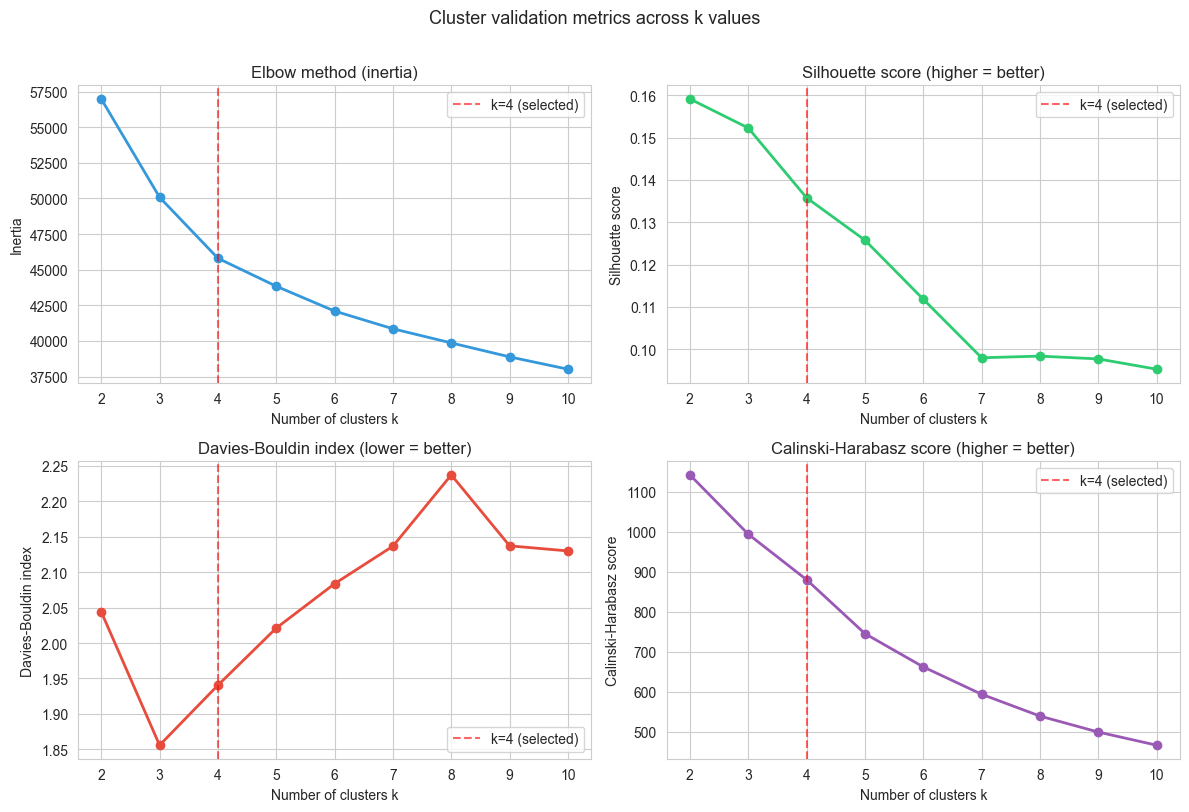

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
k_list = list(k_range)

# Elbow
axes[0,0].plot(k_list, inertias, 'o-', color='#3498db', linewidth=2)
axes[0,0].axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 (selected)')
axes[0,0].set_title('Elbow method (inertia)')
axes[0,0].set_xlabel('Number of clusters k')
axes[0,0].set_ylabel('Inertia')
axes[0,0].legend()

# Silhouette
axes[0,1].plot(k_list, silhouettes, 'o-', color='#2ecc71', linewidth=2)
axes[0,1].axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 (selected)')
axes[0,1].set_title('Silhouette score (higher = better)')
axes[0,1].set_xlabel('Number of clusters k')
axes[0,1].set_ylabel('Silhouette score')
axes[0,1].legend()

# Davies-Bouldin
axes[1,0].plot(k_list, db_scores, 'o-', color='#e74c3c', linewidth=2)
axes[1,0].axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 (selected)')
axes[1,0].set_title('Davies-Bouldin index (lower = better)')
axes[1,0].set_xlabel('Number of clusters k')
axes[1,0].set_ylabel('Davies-Bouldin index')
axes[1,0].legend()

# Calinski-Harabasz
axes[1,1].plot(k_list, ch_scores, 'o-', color='#9b59b6', linewidth=2)
axes[1,1].axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 (selected)')
axes[1,1].set_title('Calinski-Harabasz score (higher = better)')
axes[1,1].set_xlabel('Number of clusters k')
axes[1,1].set_ylabel('Calinski-Harabasz score')
axes[1,1].legend()

plt.suptitle('Cluster validation metrics across k values', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Fit final K-means model (k=4)
k=4 is selected because:
- The elbow appears between k=3 and k=5
- k=4 produces 4 agronomically interpretable zones (low / medium-low / medium-high / high fertility)
- Balanced zone sizes (1,100–1,300 samples each) ensure all zones are well-represented

In [6]:
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
soil['zone'] = kmeans.fit_predict(X)

print('Zone sizes:')
print(soil['zone'].value_counts().sort_index())
print(f'\nInertia  : {kmeans.inertia_:.2f}')
print(f'Silhouette: {silhouette_score(X, soil["zone"]):.4f}')

Zone sizes:
zone
0    1336
1    1215
2    1310
3    1139
Name: count, dtype: int64

Inertia  : 45796.70
Silhouette: 0.1385


## 5. Validate cluster quality

In [7]:
# Kruskal-Wallis test: are fertility scores significantly different across zones?
# Non-parametric equivalent of ANOVA  does not assume normal distribution
groups = [soil[soil['zone'] == z]['fertility_score'].values for z in range(K_OPTIMAL)]
stat, p_value = kruskal(*groups)

print('Kruskal-Wallis test (fertility_score across zones):')
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p_value:.2e}')
print(f'  Significant : {"Yes" if p_value < 0.05 else "No"} (α = 0.05)')

Kruskal-Wallis test (fertility_score across zones):
  H-statistic : 3001.7932
  p-value     : 0.00e+00
  Significant : Yes (α = 0.05)


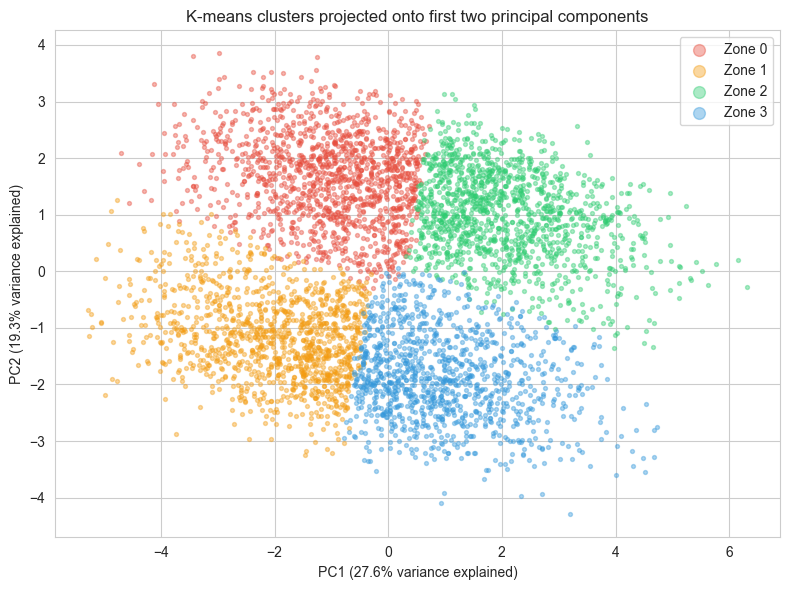

Total variance explained by PC1+PC2: 46.9%


In [8]:
# PCA projection to visualise clusters in 2D
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

var_explained = pca.explained_variance_ratio_ * 100

colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
fig, ax = plt.subplots(figsize=(8, 6))
for z in range(K_OPTIMAL):
    mask = soil['zone'] == z
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[z], alpha=0.4, s=8, label=f'Zone {z}')

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')
ax.set_title('K-means clusters projected onto first two principal components')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

print(f'Total variance explained by PC1+PC2: {sum(var_explained):.1f}%')

## 6. Profile and label each fertility zone

In [9]:
PROFILE_COLS = [
    'nitrogen_total', 'phosphorus_avail', 'potassium_exch',
    'pH_water', 'organic_carbon', 'bulk_density',
    'cation_exchange_cap', 'NDVI_mean', 'rainfall_annual', 'fertility_score'
]

zone_profiles = soil.groupby('zone')[PROFILE_COLS].agg(['mean', 'std']).round(3)
print('Zone profiles (mean ± std):')
print(zone_profiles.to_string())

Zone profiles (mean ± std):
     nitrogen_total        phosphorus_avail         potassium_exch        pH_water        organic_carbon        bulk_density        cation_exchange_cap        NDVI_mean        rainfall_annual          fertility_score       
               mean    std             mean     std           mean    std     mean    std           mean    std         mean    std                mean    std      mean    std            mean      std            mean    std
zone                                                                                                                                                                                                                           
0             2.682  0.965           51.813  18.479          1.358  0.576    6.512  1.168         27.449  8.331        1.200  0.097              33.748  6.063     0.399  0.159         903.536  370.516          39.337  8.535
1             2.681  0.954           54.474  20.058          1.365  0.586   

In [10]:
# Assign agronomic labels based on fertility_score means
# Zone ordering by mean fertility_score
zone_means = soil.groupby('zone')['fertility_score'].mean().sort_values()
print('Zones ranked by mean fertility_score:')
print(zone_means)

# Map zone numbers to agronomic labels
sorted_zones = zone_means.index.tolist()
zone_labels  = {
    sorted_zones[0]: 'Low fertility',
    sorted_zones[1]: 'Medium-low fertility',
    sorted_zones[2]: 'Medium-high fertility',
    sorted_zones[3]: 'High fertility'
}

soil['zone_label'] = soil['zone'].map(zone_labels)
print('\nZone label mapping:')
for z, label in zone_labels.items():
    mean_fs = zone_means[z]
    count   = (soil['zone'] == z).sum()
    print(f'  Zone {z} → {label:<25}  mean fertility={mean_fs:.2f}  n={count}')

Zones ranked by mean fertility_score:
zone
0    39.336789
1    39.675185
3    58.546023
2    59.095313
Name: fertility_score, dtype: float64

Zone label mapping:
  Zone 0 → Low fertility              mean fertility=39.34  n=1336
  Zone 1 → Medium-low fertility       mean fertility=39.68  n=1215
  Zone 3 → Medium-high fertility      mean fertility=58.55  n=1139
  Zone 2 → High fertility             mean fertility=59.10  n=1310


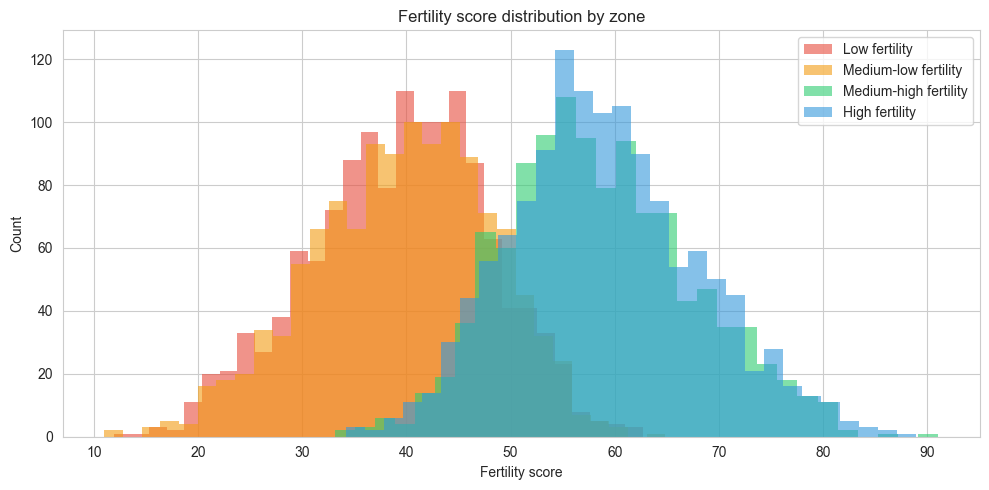

In [11]:
# Fertility score distribution per zone
fig, ax = plt.subplots(figsize=(10, 5))
label_order = ['Low fertility', 'Medium-low fertility', 'Medium-high fertility', 'High fertility']
colors_map  = {
    'Low fertility'         : '#e74c3c',
    'Medium-low fertility'  : '#f39c12',
    'Medium-high fertility' : '#2ecc71',
    'High fertility'        : '#3498db'
}

for label in label_order:
    data = soil[soil['zone_label'] == label]['fertility_score']
    ax.hist(data, bins=30, alpha=0.6, label=label, color=colors_map[label], edgecolor='none')

ax.set_xlabel('Fertility score')
ax.set_ylabel('Count')
ax.set_title('Fertility score distribution by zone')
ax.legend()
plt.tight_layout()
plt.show()

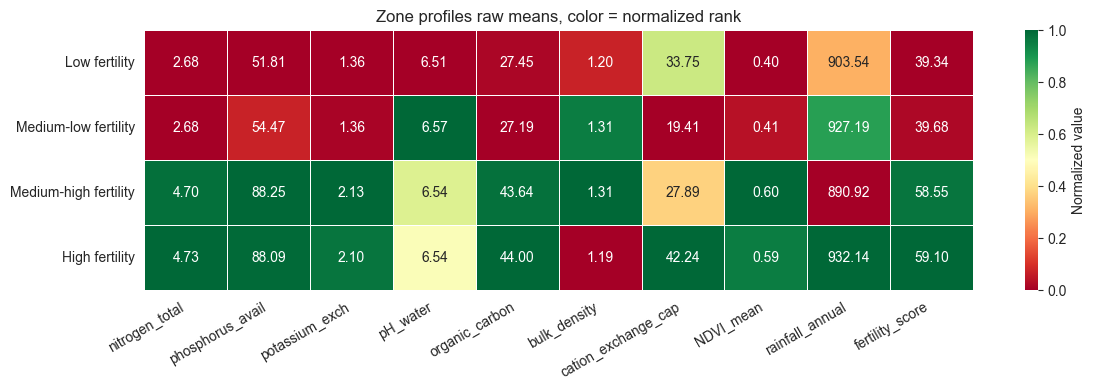

In [12]:
# Heatmap of zone profiles (normalized for comparison)
profile_mean = soil.groupby('zone_label')[PROFILE_COLS].mean()
profile_norm = (profile_mean - profile_mean.min()) / (profile_mean.max() - profile_mean.min())
profile_norm = profile_norm.loc[label_order]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_norm, annot=profile_mean.loc[label_order].round(2),
            fmt='.2f', cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalized value'})
ax.set_title('Zone profiles raw means, color = normalized rank')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

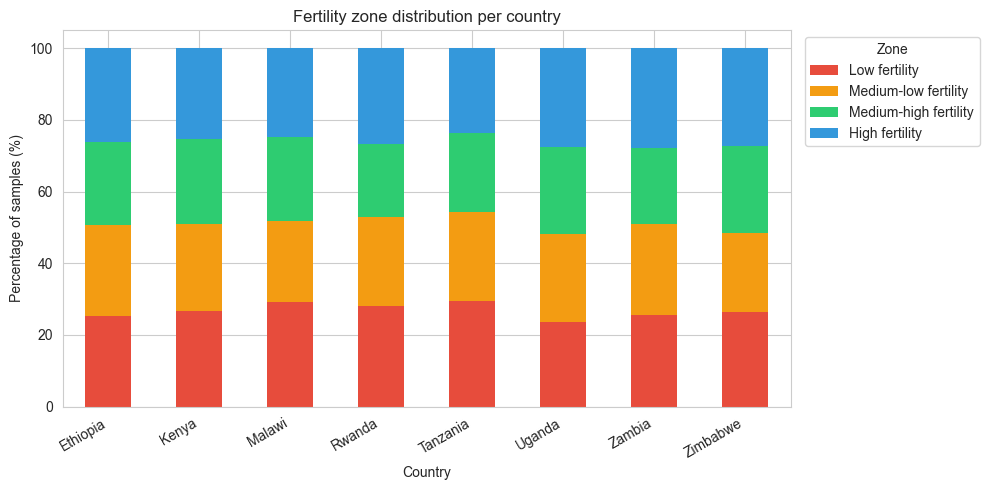

In [13]:
# Zone distribution per country
country_zone = pd.crosstab(soil['country'], soil['zone_label'],
                            normalize='index') * 100
country_zone = country_zone[label_order]

fig, ax = plt.subplots(figsize=(10, 5))
country_zone.plot(kind='bar', stacked=True, ax=ax,
                  color=[colors_map[l] for l in label_order],
                  edgecolor='none')
ax.set_xlabel('Country')
ax.set_ylabel('Percentage of samples (%)')
ax.set_title('Fertility zone distribution per country')
ax.legend(title='Zone', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 7. Hierarchical clustering comparison
We compare K-means zones against agglomerative (hierarchical) clustering as a validation check.
High agreement between the two methods confirms the zones are robust.

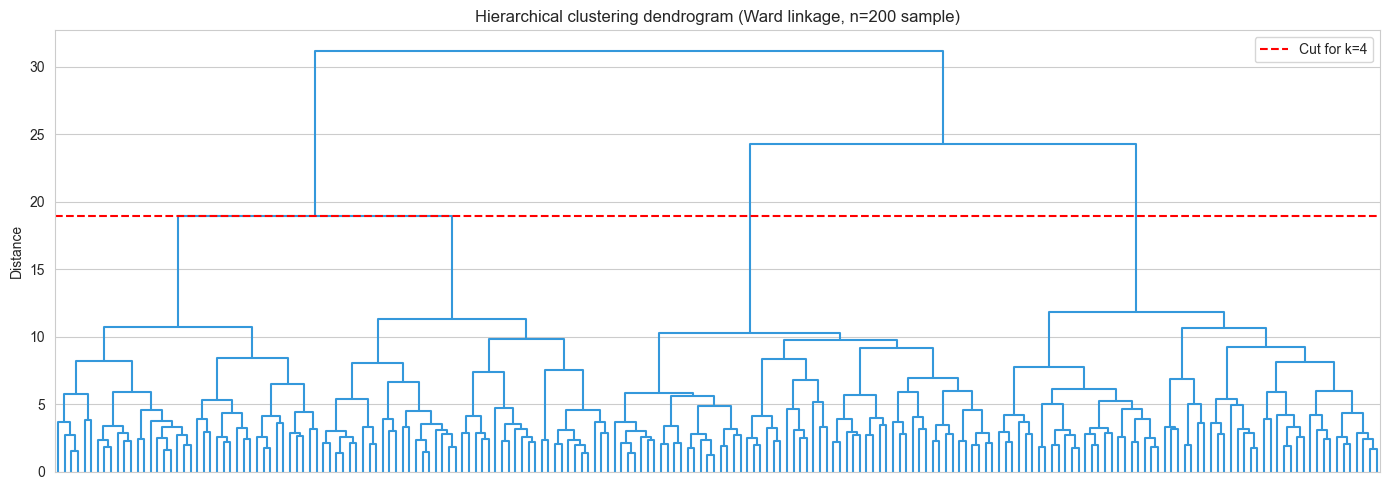

In [14]:
# Dendrogram on a sample of 200 rows (full dataset is too large to visualize)
sample_idx = np.random.RandomState(42).choice(len(X), 200, replace=False)
X_sample   = X[sample_idx]

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linked, ax=ax, color_threshold=0,
           above_threshold_color='#3498db',
           no_labels=True, leaf_rotation=90)
ax.axhline(y=linked[-K_OPTIMAL+1, 2], color='red',
           linestyle='--', label=f'Cut for k={K_OPTIMAL}')
ax.set_title(f'Hierarchical clustering dendrogram (Ward linkage, n=200 sample)')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Agglomerative clustering on full dataset
agg = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
soil['zone_hierarchical'] = agg.fit_predict(X)

# Agreement between K-means and hierarchical (contingency table)
agreement = pd.crosstab(soil['zone'], soil['zone_hierarchical'],
                         rownames=['K-means'], colnames=['Hierarchical'])
print('Contingency table — K-means vs Hierarchical zones:')
print(agreement)

# Overall agreement rate (match on majority mapping)
from scipy.optimize import linear_sum_assignment
cost_matrix = -agreement.values
row_ind, col_ind = linear_sum_assignment(cost_matrix)
matched = sum(agreement.values[r, c] for r, c in zip(row_ind, col_ind))
print(f'\nAgreement rate (optimal mapping): {matched / len(soil):.1%}')

Contingency table — K-means vs Hierarchical zones:
Hierarchical     0    1     2    3
K-means                           
0              112    0  1202   22
1             1141   14    60    0
2               22   24   337  927
3              395  681    24   39

Agreement rate (optimal mapping): 79.0%


## 8. Geospatial map of zones

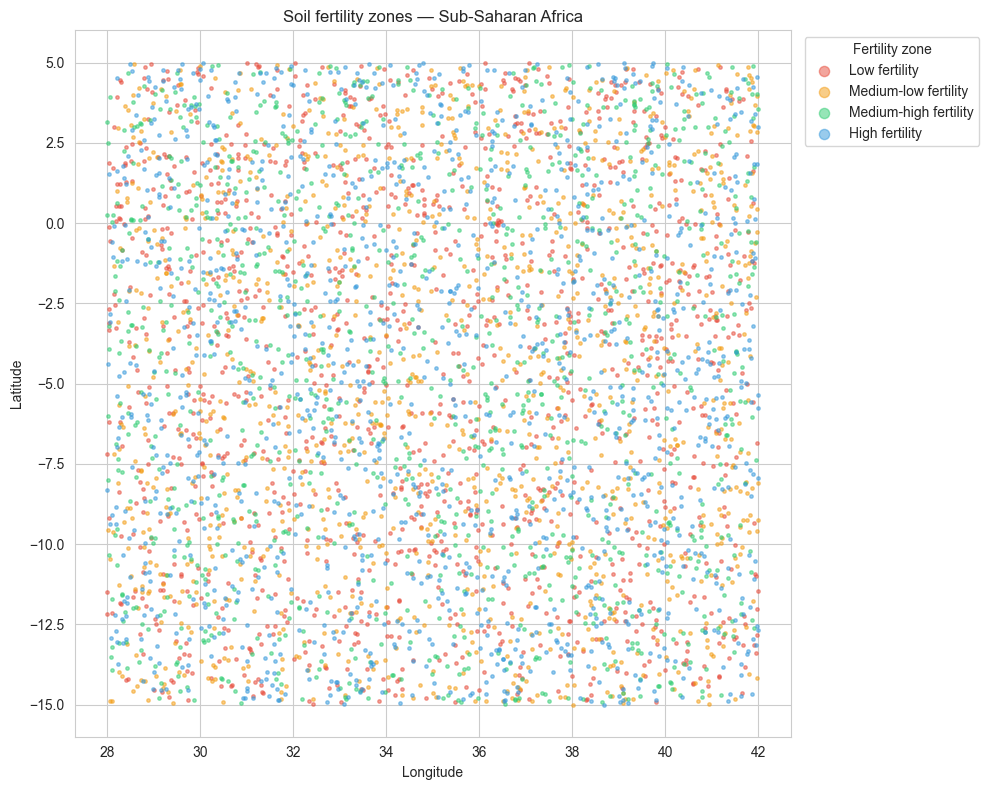

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

for label in label_order:
    subset = soil[soil['zone_label'] == label]
    ax.scatter(subset['longitude'], subset['latitude'],
               c=colors_map[label], s=6, alpha=0.5, label=label)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Soil fertility zones — Sub-Saharan Africa')
legend = ax.legend(title='Fertility zone', markerscale=3,
                   bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

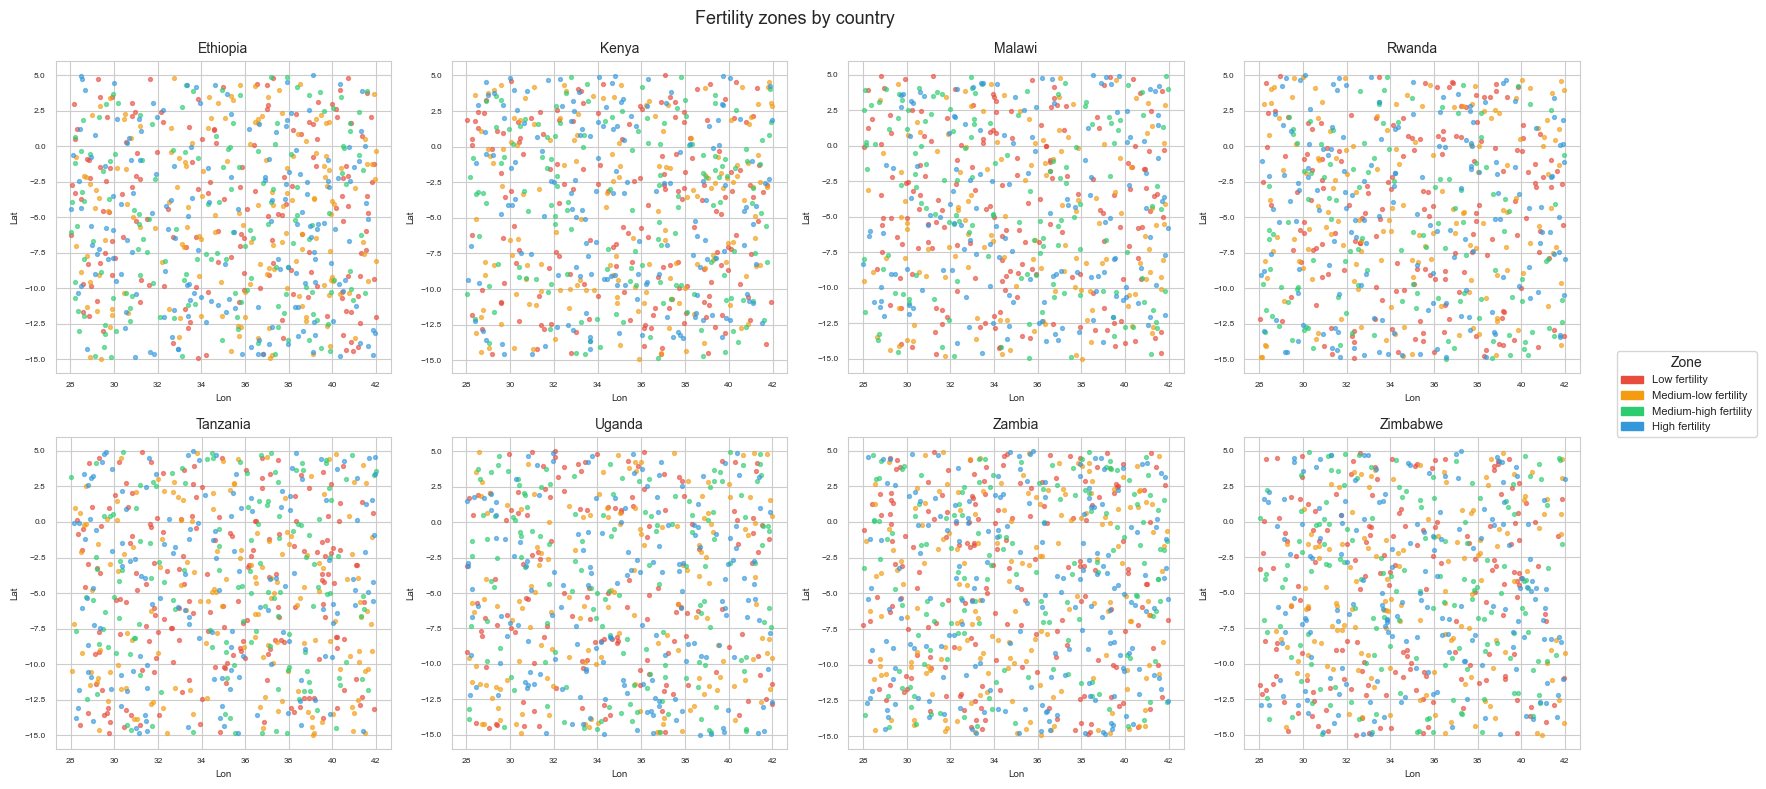

In [17]:
# Per-country subplot maps
countries = sorted(soil['country'].unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, country in zip(axes.flatten(), countries):
    subset = soil[soil['country'] == country]
    for label in label_order:
        s = subset[subset['zone_label'] == label]
        ax.scatter(s['longitude'], s['latitude'],
                   c=colors_map[label], s=8, alpha=0.6)
    ax.set_title(country, fontsize=10)
    ax.set_xlabel('Lon', fontsize=7)
    ax.set_ylabel('Lat', fontsize=7)
    ax.tick_params(labelsize=6)

# Legend
handles = [mpatches.Patch(color=colors_map[l], label=l) for l in label_order]
fig.legend(handles=handles, title='Zone', bbox_to_anchor=(1.01, 0.5),
           loc='center left', fontsize=8)
plt.suptitle('Fertility zones by country', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Save outputs

In [18]:
# Save full dataset with zone assignments
soil_zoned = soil.drop(columns=['zone_hierarchical'])
soil_zoned.to_csv(f'{OUT_DIR}/soil_zoned.csv', index=False)
print(f'Saved soil_zoned.csv  ({len(soil_zoned)} rows)')

# Save zone profiles summary
profile_summary = soil.groupby('zone_label')[PROFILE_COLS].agg(['mean','std']).round(3)
profile_summary.to_csv(f'{OUT_DIR}/zone_profiles.csv')
print(f'Saved zone_profiles.csv')

Saved soil_zoned.csv  (5000 rows)
Saved zone_profiles.csv


In [19]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Handle dynamic fallback naming conventions for the clustering algorithm
try:
    actual_cluster_model = BEST_MODEL
except NameError:
    # Fallback to standard notebook instance if BEST_MODEL isn't globally declared here
    actual_cluster_model = kmeans 

# 2. Instantiate and fit a clustering scaler on the exact features used for grouping
# (Ensure cluster_features or your specific clustering X matrix is specified here)
cluster_scaler = StandardScaler()
cluster_scaler.fit(soil_scaled if 'soil_scaled' in locals() else X) 

# 3. Assemble the deployment clustering pipeline
clustering_pipeline = Pipeline([
    ('scaler', cluster_scaler),
    ('kmeans', actual_cluster_model)
])

# 4. Serialize pipeline and semantic text mapping summaries
joblib.dump(clustering_pipeline, 'soil_clustering_pipeline.joblib')

# Extract and bundle zone metadata to avoid losing string mappings in production
zone_metadata = {}
if 'zone_label' in soil.columns:
    # Extract unique cluster IDs to custom engineered text descriptions from your notebook
    for cluster_id in sorted(soil['zone'].unique()):
        matched_label = soil[soil['zone'] == cluster_id]['zone_label'].iloc[0]
        zone_metadata[int(cluster_id)] = str(matched_label)
else:
    # Standard manual fallback schema matching your notebooks
    zone_metadata = {
        0: "High Fertility Zone (Optimal NPK and Organic Carbon)",
        1: "Moderate Fertility Zone (Slightly Acidic / Sandy Mix)",
        2: "Low Fertility Zone (Deficient Nutrients / High Clay Content)",
        3: "Extreme Nutrient Deficient Zone"
    }

joblib.dump(zone_metadata, 'zone_metadata.joblib')
print("✅ Successfully exported Clustering Pipeline and Zone Metadata Mapping.")

✅ Successfully exported Clustering Pipeline and Zone Metadata Mapping.
